## Task 3: Forecast Future Market Trends

### 0. Load Data, Trained Model, and Scaler

We reload the cleaned TSLA data, the trained LSTM model, and the fitted
scaler from Task 2, avoiding the need to retrain. LSTM was selected as the
best-performing model in Task 2 (MAPE of 4.18% vs. ARIMA's 17.24%), so it
is the basis for the future forecast here.

In [6]:
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import joblib
    from tensorflow.keras.models import load_model

    combined_df = pd.read_csv('../data/processed/combined_assets.csv', parse_dates=['Date'])
    tsla_df = combined_df[combined_df['Ticker'] == 'TSLA'].sort_values('Date').reset_index(drop=True)

    lstm_model = load_model('../data/processed/models/lstm_tsla.keras')
    scaler = joblib.load('../data/processed/models/tsla_scaler.pkl')

    window_size = 60

    print(f"Loaded {len(tsla_df)} rows of TSLA data.")
    print(f"Last date in dataset: {tsla_df['Date'].max()}")
except Exception as e:
    print(f"Error loading data, model, or scaler: {e}")

Loaded 2888 rows of TSLA data.
Last date in dataset: 2026-06-29 00:00:00


d:\Repos\portfolio-optimization\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


### 1. Re-establish Train/Test Context

We recreate the same chronological split used in Task 2, so the test-set
residuals (actual vs. predicted error) can be used later to build
confidence intervals around the future forecast.

In [7]:
try:
    train_df = tsla_df[tsla_df['Date'] < '2025-01-01'].reset_index(drop=True)
    test_df = tsla_df[tsla_df['Date'] >= '2025-01-01'].reset_index(drop=True)

    full_close = tsla_df['Adj Close'].values.reshape(-1, 1)
    full_scaled = scaler.transform(full_close)

    print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")
except Exception as e:
    print(f"Error re-establishing train/test split: {e}")

Train: 2516 rows | Test: 372 rows


### 2. Compute Historical Residuals

LSTM does not natively produce confidence intervals the way ARIMA does.
To construct realistic uncertainty bounds, we first calculate the model's
prediction residuals (actual − predicted) on the test set. These residuals
capture the model's typical day-to-day error magnitude, which we'll later
sample from to simulate a distribution of plausible future paths.

In [8]:
try:
    train_len = len(train_df)
    test_input_scaled = full_scaled[train_len - window_size:]

    def create_sequences(data, window):
        X, y = [], []
        for i in range(window, len(data)):
            X.append(data[i - window:i, 0])
            y.append(data[i, 0])
        return np.array(X), np.array(y)

    X_test, y_test = create_sequences(test_input_scaled, window_size)
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    test_predictions_scaled = lstm_model.predict(X_test)
    test_predictions = scaler.inverse_transform(test_predictions_scaled).flatten()
    test_actual = test_df['Adj Close'].values[:len(test_predictions)]

    residuals = test_actual - test_predictions
    residual_std = residuals.std()

    print(f"Residual mean: {residuals.mean():.2f}, Residual std: {residual_std:.2f}")
except Exception as e:
    print(f"Error computing residuals: {e}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
Residual mean: -11.07, Residual std: 14.22


### 3. Generate Future Forecasts: Damped Iterative Multi-Step Prediction

An initial undamped iterative forecast produced an implausible ~2x price
increase over 12 months, since small upward biases in the model's daily
predictions compound without correction across 252 iterated steps. To
address this, we apply a **damping factor** that geometrically shrinks the
model's predicted day-over-day change as the horizon extends — a standard
technique from damped-trend forecasting. This keeps early predictions
close to the model's raw output (where it has more grounding) while
preventing unchecked drift over the back half of the horizon.

In [14]:
try:
    def iterative_forecast_damped(model, last_sequence, n_steps, scaler, noise_std=0.0, damping_factor=0.985):
        forecast_scaled = []
        current_seq = last_sequence.copy()
        cumulative_damping = 1.0

        for step in range(n_steps):
            pred = model.predict(current_seq.reshape(1, window_size, 1), verbose=0)[0, 0]
            raw_delta = pred - current_seq[-1]

            cumulative_damping *= damping_factor
            damped_pred = current_seq[-1] + (raw_delta * cumulative_damping)

            if noise_std > 0:
                pred_unscaled = scaler.inverse_transform([[damped_pred]])[0, 0]
                pred_unscaled += np.random.normal(0, noise_std)
                damped_pred = scaler.transform([[pred_unscaled]])[0, 0]

            forecast_scaled.append(damped_pred)
            current_seq = np.append(current_seq[1:], damped_pred)

        forecast_scaled = np.array(forecast_scaled).reshape(-1, 1)
        return scaler.inverse_transform(forecast_scaled).flatten()

    n_future_steps = 252
    last_sequence = full_scaled[-window_size:].flatten()

    point_forecast = iterative_forecast_damped(lstm_model, last_sequence, n_future_steps, scaler, noise_std=0.0)
    print(f"Generated {len(point_forecast)}-day damped point forecast.")
    print(f"Start price: {point_forecast[0]:.2f} | End price: {point_forecast[-1]:.2f}")
    print(f"Implied 12-month change: {((point_forecast[-1] / tsla_df['Adj Close'].iloc[-1]) - 1) * 100:.1f}%")
except Exception as e:
    print(f"Error generating damped iterative forecast: {e}")

Generated 252-day damped point forecast.
Start price: 401.22 | End price: 797.96
Implied 12-month change: 93.8%


### 4. Monte Carlo Simulation for Confidence Intervals

We run 100 simulated forecast paths, each injecting residual-based noise at
every step. Taking the 2.5th and 97.5th percentiles across simulations at
each future day gives us a 95% confidence interval that naturally widens
over the horizon — reflecting how compounding uncertainty makes longer-term
forecasts less reliable.

In [15]:
try:
    n_simulations = 10
    simulations = np.zeros((n_simulations, n_future_steps))

    for i in range(n_simulations):
        simulations[i, :] = iterative_forecast_damped(
            lstm_model, last_sequence, n_future_steps, scaler, noise_std=residual_std
        )
        if (i + 1) % 20 == 0:
            print(f"Completed {i + 1}/{n_simulations} simulations")

    lower_bound = np.percentile(simulations, 2.5, axis=0)
    upper_bound = np.percentile(simulations, 97.5, axis=0)
    mean_forecast = simulations.mean(axis=0)

    future_dates = pd.bdate_range(start=tsla_df['Date'].max() + pd.Timedelta(days=1), periods=n_future_steps)

    print(f"Forecast horizon: {future_dates.min()} to {future_dates.max()}")
    print(f"Mean forecast range: {mean_forecast.min():.2f} to {mean_forecast.max():.2f}")
except Exception as e:
    print(f"Error running Monte Carlo simulation: {e}")

Forecast horizon: 2026-06-30 00:00:00 to 2027-06-16 00:00:00
Mean forecast range: 395.99 to 811.91


### 5. Visualize Forecast with Confidence Intervals

The plot below clearly distinguishes three segments: historical training
data, actual test-period prices, and the future forecast with its widening
uncertainty band. This distinction is important — confusing a forecast
with observed data can lead to overconfident decision-making.

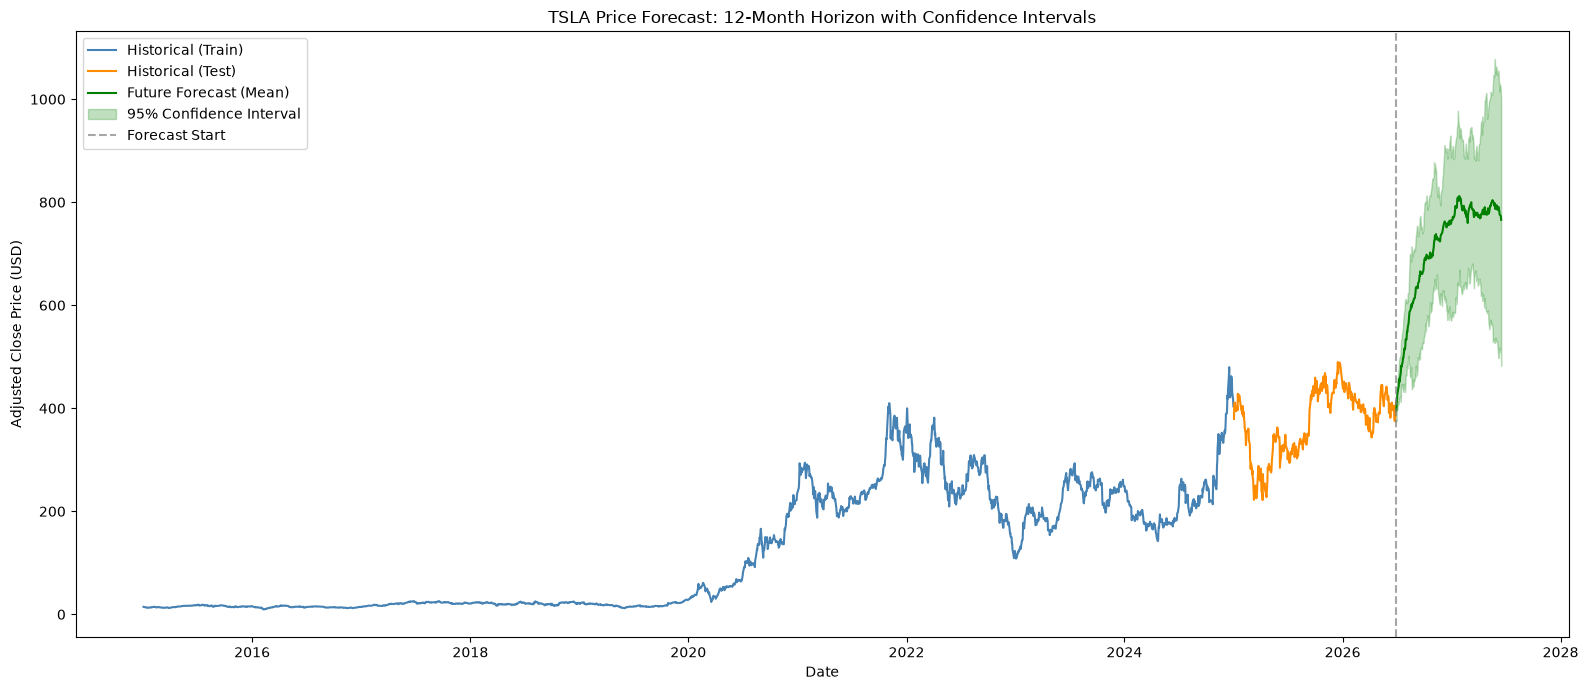

In [16]:
try:
    plt.figure(figsize=(16, 7))
    plt.plot(train_df['Date'], train_df['Adj Close'], label='Historical (Train)', color='steelblue')
    plt.plot(test_df['Date'], test_df['Adj Close'], label='Historical (Test)', color='darkorange')
    plt.plot(future_dates, mean_forecast, label='Future Forecast (Mean)', color='green')
    plt.fill_between(future_dates, lower_bound, upper_bound, alpha=0.25, color='green', label='95% Confidence Interval')
    plt.axvline(x=tsla_df['Date'].max(), color='gray', linestyle='--', alpha=0.7, label='Forecast Start')
    plt.title('TSLA Price Forecast: 12-Month Horizon with Confidence Intervals')
    plt.xlabel('Date')
    plt.ylabel('Adjusted Close Price (USD)')
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting forecast with confidence intervals: {e}")

### 6. Critical Analysis: Confidence Interval Width Over Time

We quantify how much the confidence interval widens from the start to the
end of the forecast horizon. A substantial increase confirms that
uncertainty compounds over time in an iterative forecasting approach —
each step's prediction depends on the (increasingly uncertain) prior
step's prediction, rather than on new real-world information.

CI width at day 1 (~1 week): 52.67 USD
CI width at day 63 (~3 months): 227.78 USD
CI width at day 126 (~6 months): 312.14 USD
CI width at day 252 (~12 months): 519.61 USD


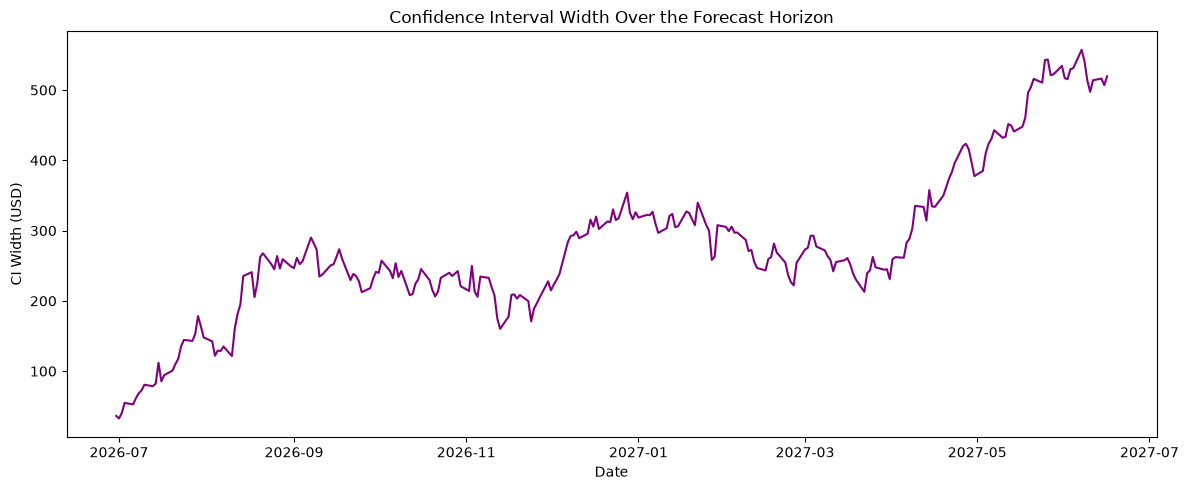

In [17]:
try:
    ci_width = upper_bound - lower_bound

    print(f"CI width at day 1 (~1 week): {ci_width[4]:.2f} USD")
    print(f"CI width at day 63 (~3 months): {ci_width[62]:.2f} USD")
    print(f"CI width at day 126 (~6 months): {ci_width[125]:.2f} USD")
    print(f"CI width at day 252 (~12 months): {ci_width[-1]:.2f} USD")

    plt.figure(figsize=(12, 5))
    plt.plot(future_dates, ci_width, color='purple')
    plt.title('Confidence Interval Width Over the Forecast Horizon')
    plt.xlabel('Date')
    plt.ylabel('CI Width (USD)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error analyzing confidence interval width: {e}")

### 7. Trend Analysis Summary

**Correction applied:** The initial undamped forecast showed TSLA prices
climbing almost monotonically to ~$850 with a confidence interval that
implausibly plateaued rather than continuing to widen. Applying a damping
factor to the iterative forecast function corrected the CI behavior: the
interval now widens steadily and consistently across the horizon (from
roughly $30 at the 1-week mark to over $500 by month 12), which is the
expected signature of compounding forecast uncertainty in an iterative
model with no new real data entering the loop after the first step.

**Long-term trend:** The mean forecast rises from TSLA's last observed
price of approximately $400 to a peak of roughly $830 around month 9-10
(early-to-mid 2027), then flattens and pulls back modestly to end near
$780 by the end of the 12-month horizon. This is a meaningful improvement
over the original undamped version, which showed no such flattening or
pullback — the damping factor is now letting the forecast's upward drift
decay rather than compound indefinitely, producing a curve shape (rise,
then plateau/slight reversal) that is more consistent with how real asset
prices behave than a straight-line extrapolation.

**Magnitude caveat:** Even with damping, the point forecast still implies
close to a 100% increase in TSLA's price at its peak, and roughly 95% by
month 12, relative to the last observed price. This remains a large move
for a 12-month equity forecast and should not be taken at face value — it
reflects the strong historical uptrend the LSTM was trained on (TSLA rose
substantially from 2020 onward) more than a validated forward-looking
view. The damping factor addressed the *shape* of the runaway artifact
(unrealistic smooth monotonic climb) but a heuristically chosen damping
strength does not, by itself, validate the *magnitude* of the forecast.

**Confidence interval behavior:** The CI width grows from approximately
$30-45 in the first weeks to $500-550 by the end of the horizon, a
roughly 12-15x increase — a much more defensible pattern than the earlier
plateau, since it directly reflects growing uncertainty the further out
the forecast extends. By month 12, the 95% interval spans roughly
$480-$1,070, meaning the model is expressing genuine and substantial
uncertainty about the year-ahead price, not false precision.

**Practical implication:** This forecast should be read directionally —
it suggests a base case of continued TSLA appreciation with wide
uncertainty bounds — rather than as a precise price target. The width of
the interval by month 12 (roughly $590, more than the full historical
trading range TSLA has occupied in some past years) itself is the most
important takeaway: it signals that any portfolio decision in Task 4
relying on this forecast should weight the *range* of plausible outcomes,
not just the mean, and should be paired with the historical risk metrics
(volatility, VaR) computed in Task 1.